In [6]:
# Importando as bibliotecas necessárias
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Função para buscar dados na API do Banco Central (SGS)
def consulta_bc(codigo_sgs):
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_sgs}/dados?formato=json'
    try:
        response = requests.get(url)
        response.raise_for_status() # Verifica se houve erro na requisição
        df = pd.DataFrame(response.json())

        # Tratamento dos dados
        df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
        df['valor'] = pd.to_numeric(df['valor'])
        df.set_index('data', inplace=True)
        return df
    except Exception as e:
        print(f"Erro ao buscar a série {codigo_sgs}: {e}")
        return pd.DataFrame()

### 4. Plotagem dos Gráficos

Neste bloco, configuramos o estilo visual com `seaborn-v0_8-darkgrid` e criamos dois subplots. O primeiro gráfico (`ax1`) exibe o **Saldo das Operações de Crédito** para Pessoas Físicas (PF), Pessoas Jurídicas (PJ) e o Total, em milhões de reais, a partir de 2010. O segundo gráfico (`ax2`) mostra a **Taxa de Inadimplência** para as mesmas categorias, em percentual. Ambos os gráficos utilizam `matplotlib.dates` para formatar o eixo x com anos.

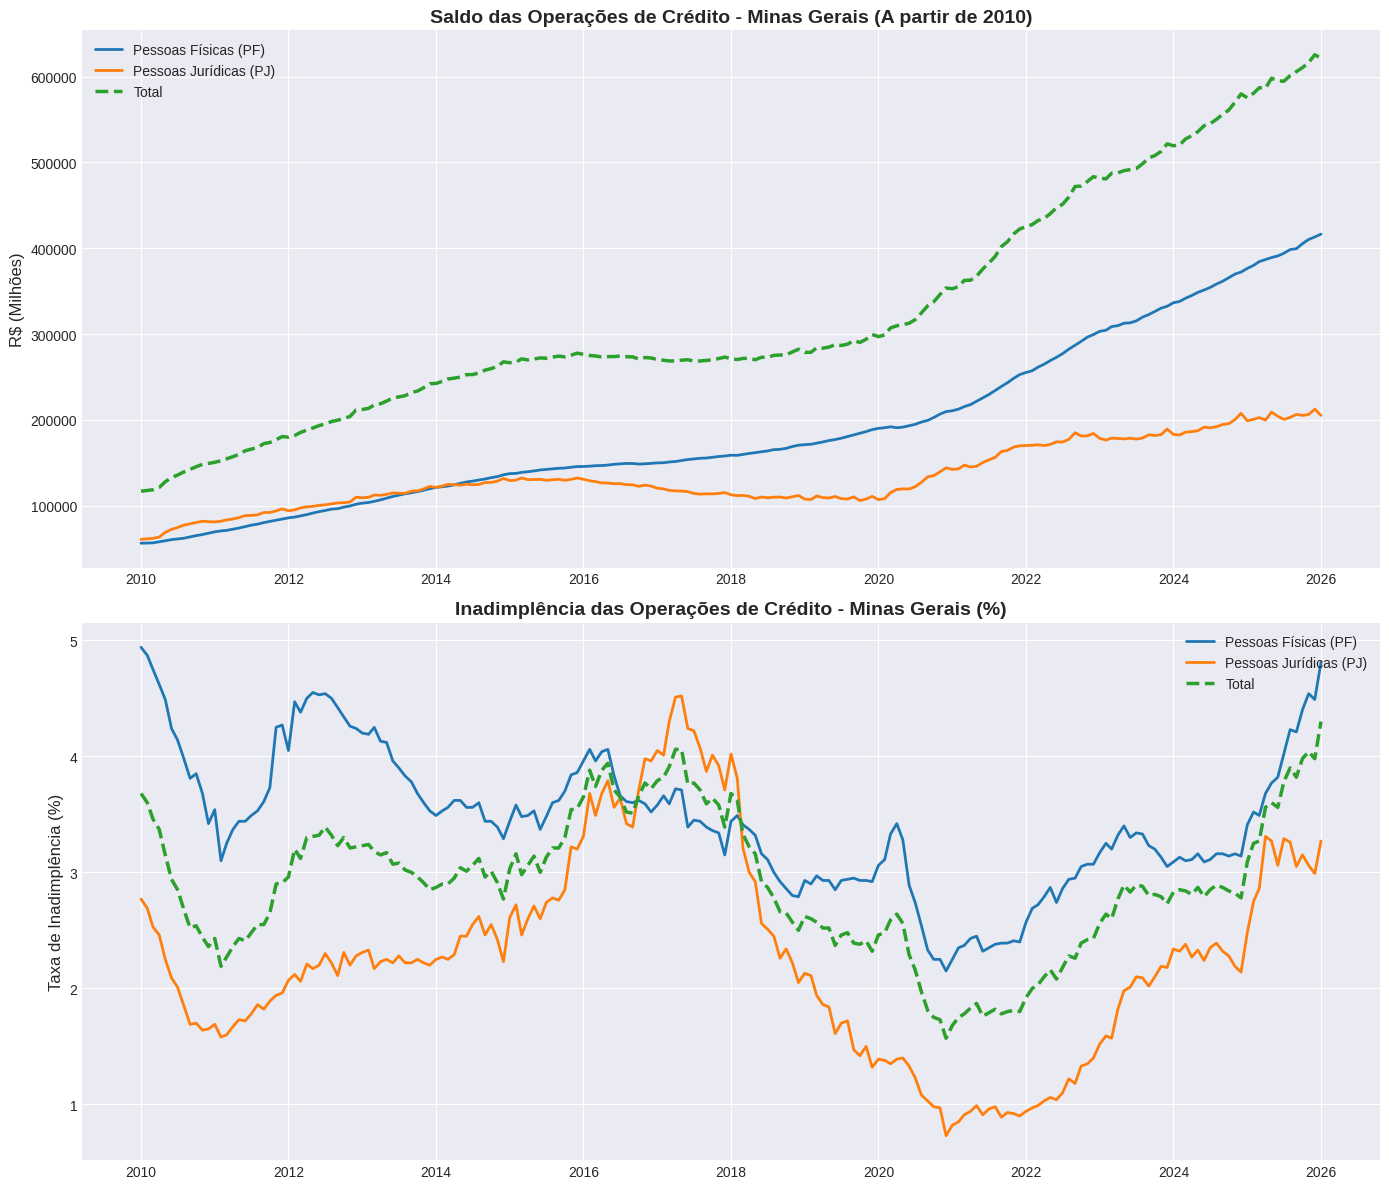

In [7]:
# Configurando o estilo visual
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Filtrando dados a partir de 2010 para melhor visualização (opcional, pode ajustar)
df_plot = df_mg.loc['2010-01-01':]

# Gráfico 1: Saldo das Operações de Crédito
ax1.plot(df_plot.index, df_plot['Saldo_PF_R$Milhoes'], label='Pessoas Físicas (PF)', color='tab:blue', linewidth=2)
ax1.plot(df_plot.index, df_plot['Saldo_PJ_R$Milhoes'], label='Pessoas Jurídicas (PJ)', color='tab:orange', linewidth=2)
ax1.plot(df_plot.index, df_plot['Saldo_Total_R$Milhoes'], label='Total', color='tab:green', linewidth=2.5, linestyle='--')
ax1.set_title('Saldo das Operações de Crédito - Minas Gerais (A partir de 2010)', fontsize=14, fontweight='bold')
ax1.set_ylabel('R$ (Milhões)', fontsize=12)
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Gráfico 2: Inadimplência das Operações de Crédito
ax2.plot(df_plot.index, df_plot['Inadimplencia_PF_%'], label='Pessoas Físicas (PF)', color='tab:blue', linewidth=2)
ax2.plot(df_plot.index, df_plot['Inadimplencia_PJ_%'], label='Pessoas Jurídicas (PJ)', color='tab:orange', linewidth=2)
ax2.plot(df_plot.index, df_plot['Inadimplencia_Total_%'], label='Total', color='tab:green', linewidth=2.5, linestyle='--')
ax2.set_title('Inadimplência das Operações de Crédito - Minas Gerais (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Inadimplência (%)', fontsize=12)
ax2.legend(loc='upper right')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3. Busca e Consolidação dos Dados

Neste bloco, iteramos sobre o dicionário `series_mg`, chamando a função `consulta_bc` para cada código de série. Os DataFrames individuais retornados são armazenados em uma lista (`dados_consolidados`) e, ao final, são concatenados em um único DataFrame (`df_mg`). Exibimos as últimas 5 linhas do `df_mg` para verificar a estrutura e os dados resultantes.

In [8]:
print("Buscando dados na API do Banco Central... Isso pode levar alguns segundos.")

# Lista para armazenar as séries e depois consolidar
dados_consolidados = []

for codigo, nome in series_mg.items():
    df_temp = consulta_bc(codigo)
    if not df_temp.empty:
        df_temp.rename(columns={'valor': nome}, inplace=True)
        dados_consolidados.append(df_temp)

# Juntando todas as séries em um único DataFrame
df_mg = pd.concat(dados_consolidados, axis=1)

# Exibindo os 5 últimos registros para conferência
print("\n--- Últimos dados tratados ---")
display(df_mg.tail())

Buscando dados na API do Banco Central... Isso pode levar alguns segundos.

--- Últimos dados tratados ---


,Saldo_PF_R$Milhoes,Saldo_PJ_R$Milhoes,Saldo_Total_R$Milhoes,Inadimplencia_PF_%,Inadimplencia_PJ_%,Inadimplencia_Total_%
data,,,,,,
2025-09-01,399493,206410,605903,4.21,3.05,3.82
2025-10-01,405293,205184,610476,4.40,3.15,3.98
2025-11-01,410256,206240,616496,4.54,3.06,4.04
2025-12-01,413110,212432,625542,4.49,2.99,3.98
2026-01-01,416486,205171,621658,4.81,3.27,4.30


### 2. Definição das Séries de Dados

Neste bloco, criamos um dicionário (`series_mg`) que mapeia os códigos de séries do Banco Central para nomes de colunas mais descritivos. Esses códigos representam diferentes indicadores econômicos para Minas Gerais, como saldos de operações de crédito e taxas de inadimplência para pessoas físicas e jurídicas.

In [9]:
# Dicionário com os códigos da imagem e nomes amigáveis para as colunas
series_mg = {
    14014: 'Saldo_PF_R$Milhoes',
    14041: 'Saldo_PJ_R$Milhoes',
    14068: 'Saldo_Total_R$Milhoes',
    15873: 'Inadimplencia_PF_%',
    15905: 'Inadimplencia_PJ_%',
    15937: 'Inadimplencia_Total_%'
}